In [1]:
import os, cv2, time, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import GradScaler, autocast   # ← AMP
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight

DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_CLASSES = 5
BATCH_SIZE  = 32      
EPOCHS      = 3       
NUM_WORKERS = 4


INCLUDE_VGG16 = False

DATA_DIR  = "/kaggle/input/aptos2019-blindness-detection"
TRAIN_CSV = os.path.join(DATA_DIR, "train.csv")
TRAIN_IMG = os.path.join(DATA_DIR, "train_images")

ENHANCED_DIR = "/kaggle/working/enhanced_images"
os.makedirs(ENHANCED_DIR, exist_ok=True)

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch: 2.9.0+cu126
CUDA available: True
GPU: Tesla T4
VRAM: 15.6 GB


In [17]:
DATA_DIR  = "/kaggle/input/competitions/aptos2019-blindness-detection"
TRAIN_CSV = os.path.join(DATA_DIR, "train.csv")
TRAIN_IMG = os.path.join(DATA_DIR, "train_images")

if not os.path.exists(TRAIN_CSV):
    # Fallback to the standard path if the competition path fails
    DATA_DIR  = "/kaggle/input/aptos2019-blindness-detection"
    TRAIN_CSV = os.path.join(DATA_DIR, "train.csv")
    TRAIN_IMG = os.path.join(DATA_DIR, "train_images")

try:
    df = pd.read_csv(TRAIN_CSV)
    df["path"] = df["id_code"].apply(lambda x: os.path.join(TRAIN_IMG, f"{x}.png"))
    
    train_df, val_df = train_test_split(
        df, 
        test_size=0.2, 
        stratify=df["diagnosis"], 
        random_state=42
    )

    print(f"Successfully loaded from: {DATA_DIR}")
    print(f"Train: {len(train_df)} | Val: {len(val_df)}")
    print("-" * 30)
    print("Diagnosis Distribution:")
    print(df["diagnosis"].value_counts().sort_index())

except FileNotFoundError:
    print("Cannot find path")

Successfully loaded from: /kaggle/input/competitions/aptos2019-blindness-detection
Train: 2929 | Val: 733
------------------------------
Diagnosis Distribution:
diagnosis
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64


In [3]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["diagnosis"]),
    y=train_df["diagnosis"]
)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)
print("Class weights:", class_weights)

Class weights: tensor([0.4057, 1.9791, 0.7332, 3.8039, 2.4822], device='cuda:0')


In [4]:
def crop_image_from_gray(img, tol=7):
    """Remove dark borders."""
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY) if img.ndim == 3 else img
    mask = gray > tol
    if not mask.any():
        return img
    return img[np.ix_(mask.any(1), mask.any(0))]

def ben_graham_preprocessing(img, sigmaX=10, size=512):
    """Crop → resize → Ben Graham contrast enhancement."""
    img = crop_image_from_gray(img)
    img = cv2.resize(img, (size, size))
    img = cv2.addWeighted(img, 4, cv2.GaussianBlur(img, (0, 0), sigmaX), -4, 128)
    return img

def presave_enhanced_images(df, out_dir):
    """
    Run Ben Graham preprocessing once for the whole dataset and save
    results as JPEG files. Each subsequent epoch just loads a JPEG
    instead of re-doing the OpenCV pipeline — much faster I/O.
    """
    already_done = len(os.listdir(out_dir)) >= len(df)
    if already_done:
        print(f"Enhanced images already exist in {out_dir}")
        return

    print(f"Pre-saving {len(df)} enhanced images to {out_dir} ...")
    for _, row in tqdm(df.iterrows(), total=len(df), desc="Preprocessing"):
        dst = os.path.join(out_dir, os.path.basename(row["path"]))
        if os.path.exists(dst):
            continue
        img = cv2.imread(row["path"])
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = ben_graham_preprocessing(img)
        img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
        cv2.imwrite(dst, img_bgr, [cv2.IMWRITE_JPEG_QUALITY, 95])
    print("Done.")

presave_enhanced_images(df, ENHANCED_DIR)

train_df_enhanced = train_df.copy()
val_df_enhanced   = val_df.copy()
train_df_enhanced["path"] = train_df_enhanced["id_code"].apply(
    lambda x: os.path.join(ENHANCED_DIR, x + ".png"))
val_df_enhanced["path"] = val_df_enhanced["id_code"].apply(
    lambda x: os.path.join(ENHANCED_DIR, x + ".png"))

Pre-saving 3662 enhanced images to /kaggle/working/enhanced_images ...


Preprocessing: 100%|██████████| 3662/3662 [12:46<00:00,  4.78it/s]

Done.


In [7]:
class APTOSDataset(Dataset):
    def __init__(self, df, transform=None):
        self.paths      = df["path"].values         
        self.labels     = df["diagnosis"].values.astype(np.int64)
        self.transform  = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.paths[idx])
        if img is None:
            raise FileNotFoundError(self.paths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(self.labels[idx], dtype=torch.long)

In [8]:
def get_transforms(model_name, is_train=True):
    size = 300 if "efficientnet_b3" in model_name else 224
    norm = transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    if is_train:
        return transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((size, size)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.ColorJitter(brightness=0.1, contrast=0.1),  
            transforms.ToTensor(),
            norm
        ])
    return transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((size, size)),
        transforms.ToTensor(),
        norm
    ])


def get_loaders(model_name, preprocessing_type):
    if preprocessing_type == "enhanced":
        tr_df, vl_df = train_df_enhanced, val_df_enhanced
    else:
        tr_df, vl_df = train_df, val_df

    train_tf = get_transforms(model_name, is_train=True)
    val_tf   = get_transforms(model_name, is_train=False)

    train_loader = DataLoader(
        APTOSDataset(tr_df, train_tf),
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        persistent_workers=True,  
        prefetch_factor=2,         
        drop_last=True,
    )
    val_loader = DataLoader(
        APTOSDataset(vl_df, val_tf),
        batch_size=BATCH_SIZE * 2,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        persistent_workers=True,
        prefetch_factor=2,
    )
    return train_loader, val_loader

In [9]:
def get_model(name):
    weights_map = {
        "resnet50":       (models.resnet50,       models.ResNet50_Weights.DEFAULT),
        "densenet121":    (models.densenet121,     models.DenseNet121_Weights.DEFAULT),
        "efficientnet_b3":(models.efficientnet_b3, models.EfficientNet_B3_Weights.DEFAULT),
        "vgg16":          (models.vgg16,           models.VGG16_Weights.DEFAULT),
    }
    constructor, weights = weights_map[name]
    model = constructor(weights=weights)

    if name == "vgg16":
        model.classifier[6] = nn.Linear(4096, NUM_CLASSES)
    elif name == "resnet50":
        model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
    elif name == "densenet121":
        model.classifier = nn.Linear(model.classifier.in_features, NUM_CLASSES)
    elif name == "efficientnet_b3":
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, NUM_CLASSES)

    return model.to(DEVICE)

In [11]:
def train_model(model, train_loader, val_loader, epochs=EPOCHS):
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    scaler    = GradScaler()   

    best_acc   = 0.0
    best_state = copy.deepcopy(model.state_dict())
    start      = time.time()

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0

        pbar = tqdm(train_loader, desc=f"Ep {epoch}/{epochs} [train]", leave=False)
        for imgs, labels in pbar:
            imgs, labels = imgs.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)  

            with autocast():                         
                outputs = model(imgs)
                loss    = criterion(outputs, labels)

            scaler.scale(loss).backward()             
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item()
            pbar.set_postfix(loss=f"{loss.item():.4f}")

        scheduler.step()

        model.eval()
        preds, targets = [], []

        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs = imgs.to(DEVICE, non_blocking=True)
                with autocast():
                    outputs = model(imgs)
                _, pred = torch.max(outputs, 1)
                preds.extend(pred.cpu().numpy())
                targets.extend(labels.numpy())

        acc = accuracy_score(targets, preds)
        print(f"  Epoch {epoch} | loss={running_loss/len(train_loader):.4f} | val_acc={acc:.4f}")

        if acc > best_acc:
            best_acc   = acc
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    return model, time.time() - start

In [12]:
def evaluate_model(model, val_loader):
    model.eval()
    preds, targets, probs = [], [], []

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs = imgs.to(DEVICE, non_blocking=True)
            with autocast():
                outputs = model(imgs)
            prob = torch.softmax(outputs.float(), dim=1)
            _, pred = torch.max(outputs, 1)
            preds.extend(pred.cpu().numpy())
            targets.extend(labels.numpy())
            probs.extend(prob.cpu().numpy())

    acc   = accuracy_score(targets, preds)
    f1    = f1_score(targets, preds, average="weighted")
    kappa = cohen_kappa_score(targets, preds)
    try:
        auc = roc_auc_score(targets, probs, multi_class="ovr")
    except Exception:
        auc = 0.0

    return acc, f1, kappa, auc

In [13]:
models_list = ["vgg16", "resnet50", "densenet121", "efficientnet_b3"]

preprocessing_types = ["basic", "enhanced"]
results = []

for prep in preprocessing_types:
    for model_name in models_list:
        print(f"\n{'='*50}")
        print(f" Model: {model_name}   |   Preprocessing: {prep}")
        print(f"{'='*50}")

        train_loader, val_loader = get_loaders(model_name, prep)
        model = get_model(model_name)

        model, train_time = train_model(model, train_loader, val_loader)
        acc, f1, kappa, auc = evaluate_model(model, val_loader)

        row = {
            "Model":         model_name,
            "Preprocessing": prep,
            "Accuracy":      round(acc,   4),
            "F1":            round(f1,    4),
            "Kappa":         round(kappa, 4),
            "AUC":           round(auc,   4),
            "Train_Time_s":  round(train_time, 1),
        }
        results.append(row)
        print(f"  → acc={acc:.4f}  f1={f1:.4f}  kappa={kappa:.4f}  auc={auc:.4f}  "
              f"time={train_time/60:.1f} min")

        pd.DataFrame(results).to_csv("/kaggle/working/benchmark_results_temp.csv", index=False)

        # Free GPU memory before next model
        del model, train_loader, val_loader
        torch.cuda.empty_cache()

print("All experiments complete!")


 Model: vgg16   |   Preprocessing: basic
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 207MB/s] 
/tmp/ipykernel_55/3543465741.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = GradScaler()   # ← AMP gradient scaler
Ep 1/3 [train]:   0%|          | 0/91 [00:00<?, ?it/s]/tmp/ipykernel_55/3543465741.py:24: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():                          # ← forward in FP16
/tmp/ipykernel_55/3543465741.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  Epoch 1 | loss=1.1610 | val_acc=0.6821


Ep 2/3 [train]:   0%|          | 0/91 [00:00<?, ?it/s]/tmp/ipykernel_55/3543465741.py:24: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():                          # ← forward in FP16
/tmp/ipykernel_55/3543465741.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  Epoch 2 | loss=0.9262 | val_acc=0.7790


...

  Epoch 2 | loss=0.8884 | val_acc=0.7613


Ep 3/3 [train]:   0%|          | 0/91 [00:00<?, ?it/s]/tmp/ipykernel_55/3543465741.py:24: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():                          # ← forward in FP16
/tmp/ipykernel_55/3543465741.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  Epoch 3 | loss=0.7541 | val_acc=0.7940


/tmp/ipykernel_55/774391411.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  → acc=0.7940  f1=0.7968  kappa=0.6920  auc=0.9312  time=1.7 min

✅ All experiments complete!


In [14]:
df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))
df_results.to_csv("/kaggle/working/experiment_results.csv", index=False)

          Model Preprocessing  Accuracy     F1  Kappa    AUC  Train_Time_s
          vgg16         basic    0.7790 0.7839 0.6702 0.9250         509.0
       resnet50         basic    0.7749 0.7805 0.6648 0.9233         498.1
    densenet121         basic    0.7817 0.7903 0.6775 0.9396         500.3
efficientnet_b3         basic    0.7790 0.7834 0.6710 0.9310         535.4
          vgg16      enhanced    0.7517 0.7624 0.6365 0.9258          84.7
       resnet50      enhanced    0.7558 0.7638 0.6403 0.9252          53.5
    densenet121      enhanced    0.7790 0.7853 0.6740 0.9336          59.7
efficientnet_b3      enhanced    0.7940 0.7968 0.6920 0.9312         103.6


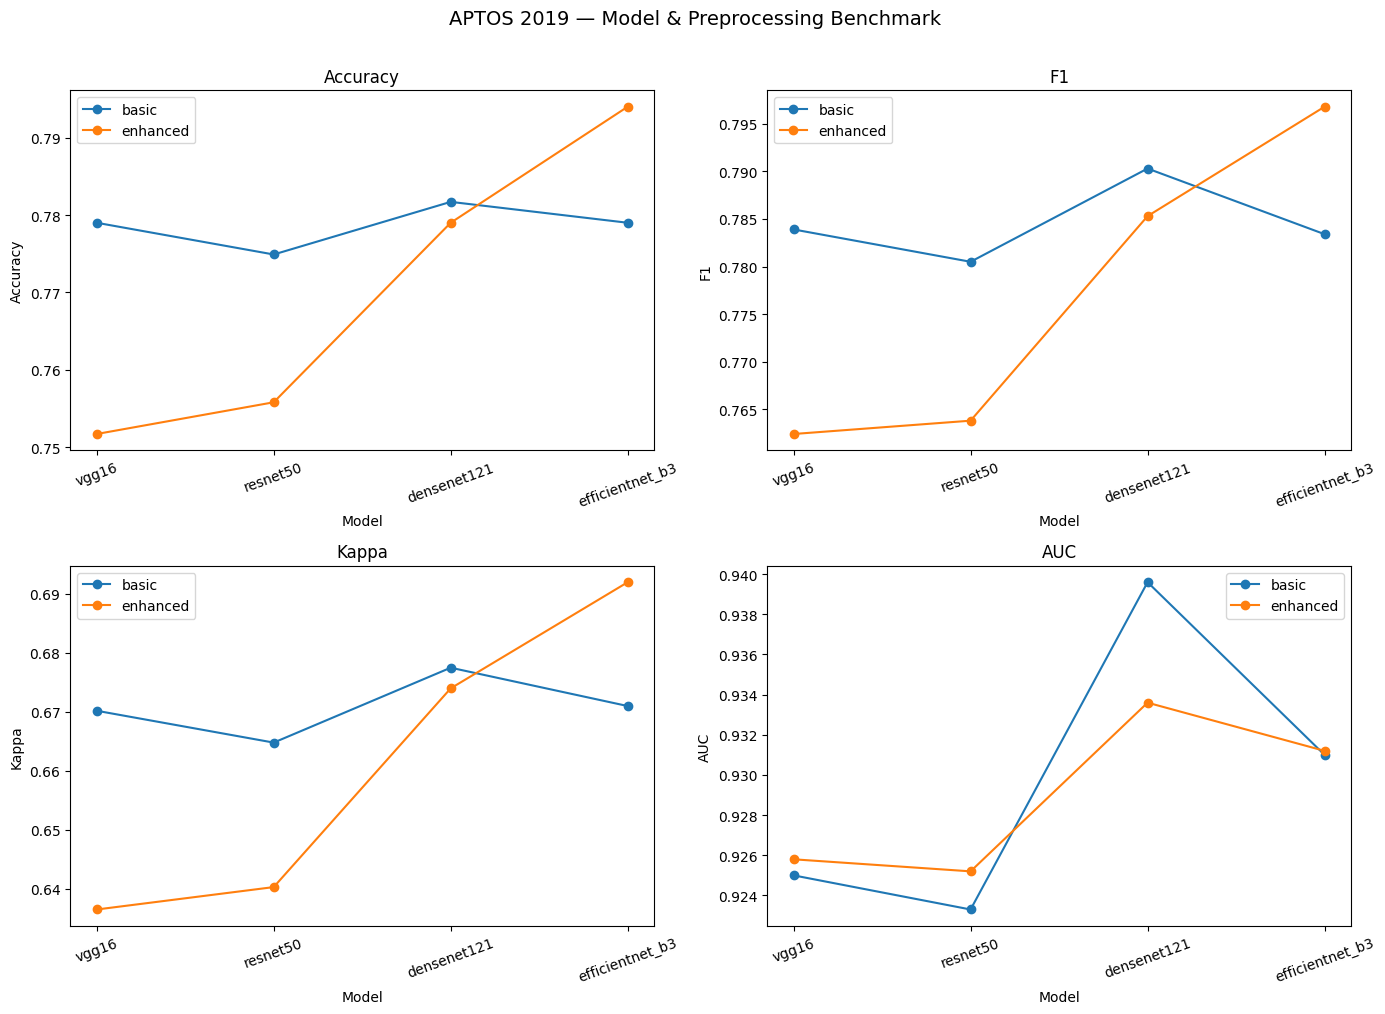

In [15]:
metrics = ["Accuracy", "F1", "Kappa", "AUC"]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, metric in zip(axes.flat, metrics):
    for prep in preprocessing_types:
        subset = df_results[df_results["Preprocessing"] == prep]
        ax.plot(subset["Model"], subset[metric], marker="o", label=prep)
    ax.set_title(metric)
    ax.set_xlabel("Model")
    ax.set_ylabel(metric)
    ax.legend()
    ax.tick_params(axis="x", rotation=20)

plt.suptitle("APTOS 2019 — Model & Preprocessing Benchmark", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("/kaggle/working/benchmark_plots.png", dpi=120, bbox_inches="tight")
plt.show()

In [18]:
best = df_results.sort_values("Kappa", ascending=False).iloc[0]
print("Best Configuration (by Kappa):")
for k, v in best.items():
    print(f"   {k:20s}: {v}")

Best Configuration (by Kappa):
   Model               : efficientnet_b3
   Preprocessing       : enhanced
   Accuracy            : 0.794
   F1                  : 0.7968
   Kappa               : 0.692
   AUC                 : 0.9312
   Train_Time_s        : 103.6
